In [1]:
!pip install geopandas
!pip install seaborn
!pip install networkx
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy


# Preambulo

En esta sección cargamos los datos y los visualizamos. También construimos la matriz de adyacencia de la red de museos.

## Carga de datos de los museos

El listado de los museos, con el que se construye el [mapa](https://mapas.museosabiertos.org/museos/caba/), lo podemos encontrar [acá](https://github.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/blob/principal/data/export.geojson?short_path=bc357f3). También descargamos los barrios de CABA como complemento para los gráficos.

In [3]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')

## Visualización

<AxesSubplot: >

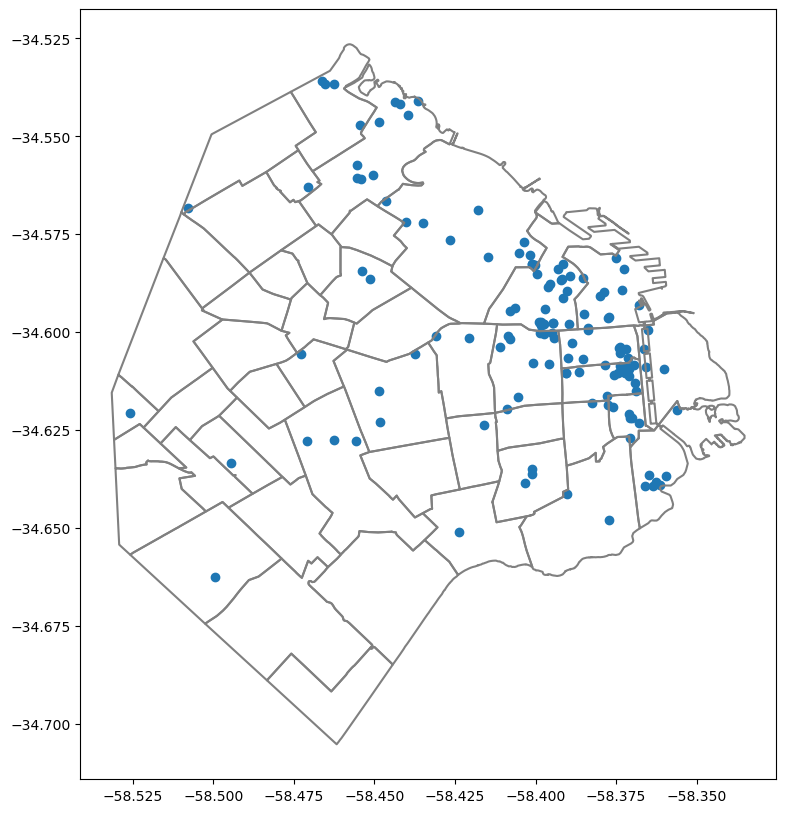

In [4]:
# Armamos el gráfico para visualizar los museos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.boundary.plot(color='gray',ax=ax)
museos.plot(ax=ax)

In [5]:
len(museos)

136

## Cálculo de la matriz de distancias

Ahora construimos la matriz de distancias entre todos los museos. Como la tierra es un [geoide](https://es.wikipedia.org/wiki/Geoide) (es decir que no es [plana](https://es.wikipedia.org/wiki/Terraplanismo)), el cálculo de distancias no es una operación obvia. Una opción es proyectar a un [sistema de coordenadas local](https://geopandas.org/en/stable/docs/user_guide/projections.html), de forma tal que las distancias euclideas se correspondan con las distancias en metros. En este notebook usamos [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) 22184. 

In [6]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa), 
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

### Matriz de adyacencia: construimos una matriz conectando a cada museo con los $m$ más cercanos

In [7]:
def construye_adyacencia(D,m): 
    # Función que construye la matriz de adyacencia del grafo de museos
    # D matriz de distancias, m cantidad de links por nodo
    # Retorna la matriz de adyacencia como un numpy.
    D = D.copy()
    l = [] # Lista para guardar las filas
    for fila in D: # recorriendo las filas, anexamos vectores lógicos
        l.append(fila<=fila[np.argsort(fila)[m]] ) # En realidad, elegimos todos los nodos que estén a una distancia menor o igual a la del m-esimo más cercano
    A = np.asarray(l).astype(int) # Convertimos a entero
    np.fill_diagonal(A,0) # Borramos diagonal para eliminar autolinks
    return(A)

m = 3 # Cantidad de links por nodo
A = construye_adyacencia(D,m)

## Construcción de la red en NetworkX (sólo para las visualizaciones)

In [8]:
G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

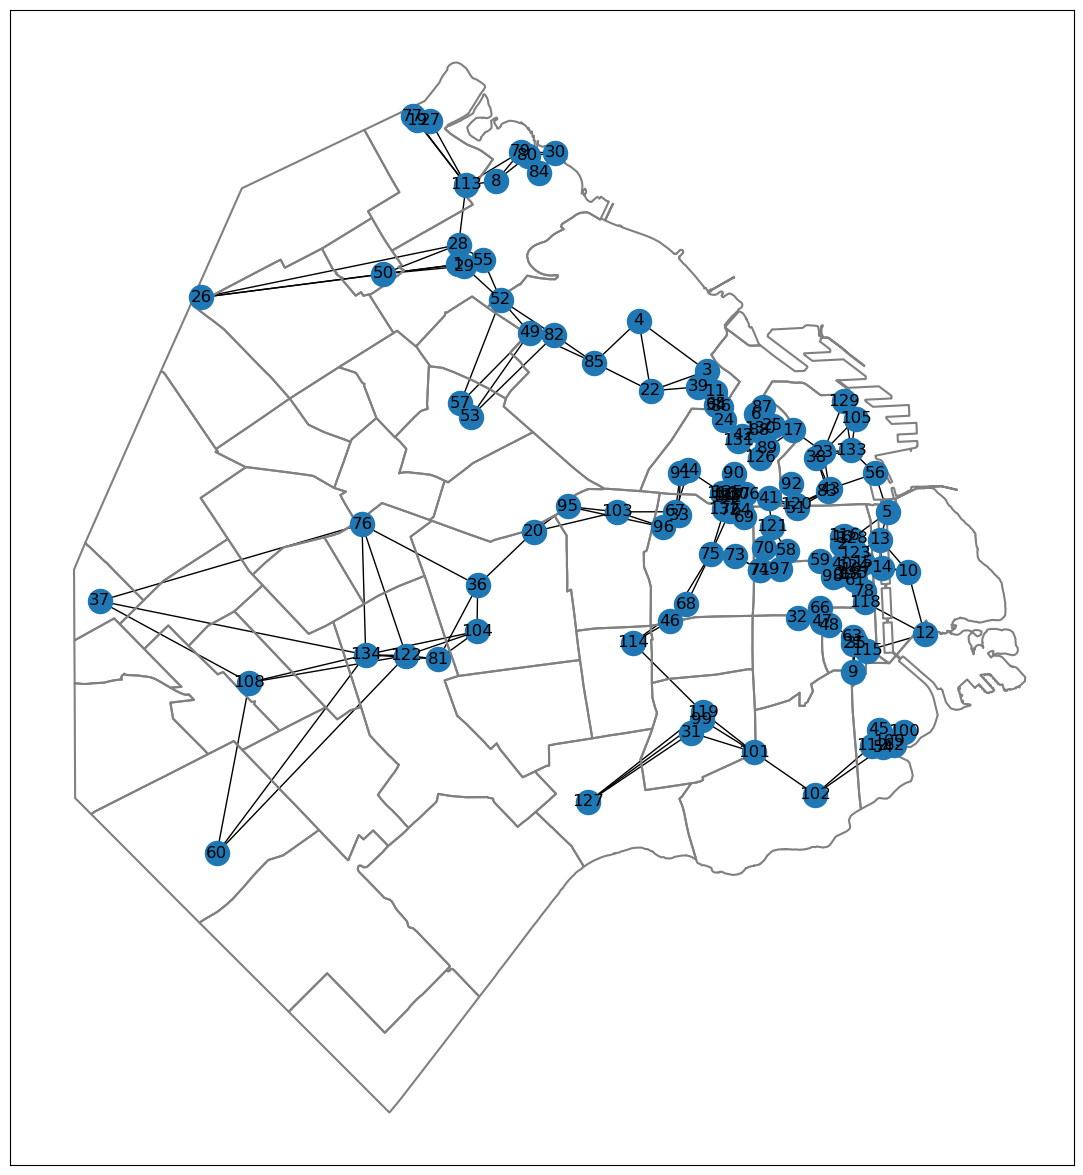

In [9]:
fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax) # Graficamos los museos

# Resolución del TP

Aquí empieza la aventura... ¡diviertanse y consulten lo que necesiten!

## Punto 1: Entendiendo nuestro dominio del problema

Partimos de la ecuación para los puntajes de las páginas combinando los escenarios de que el puntaje de cada museo depende del puntaje de otras y de la idea del navegante aleatorio:

$$p =(1- \alpha) C * p + \frac{\alpha}{N}. \overset{\rightarrow}{1}$$

Queremos ver que:

$$M*p = \overset{\rightarrow}{1} \text{ donde } \boxed{M = \frac{N}{\alpha}(I-(1-\alpha)C)}\textcolor{green}{\blacktriangledown} $$

La idea es que juntamos los términos que tengan $p$ de un lado y despejar $\overset{\rightarrow}{1}$

$$p =(1- \alpha) C * p + \frac{\alpha}{N}. \overset{\rightarrow}{1}$$

$$p - (1- \alpha) C * p = \frac{\alpha}{N}. \overset{\rightarrow}{1}$$

$$\frac{N}{\alpha}(\textcolor{red}{p} - (1- \alpha) C * \textcolor{red}{p}) = \overset{\rightarrow}{1}$$

Sacamos factor común $\textcolor{red}{p}$ y deja la matriz $I$ pues está restando a otra matriz por la propiedad de "$x−Ax=(I−A)x$" que es válida siempre que el producto esté bien definido (dimensiones compatibles), lo cual se cumple en este contexto.

$$\frac{N}{\alpha}((I - (1- \alpha) C)* \textcolor{red}{p}) = \overset{\rightarrow}{1}$$

Luego por asociatividad del producto se puede hacer:

$$[\frac{N}{\alpha}(I - (1- \alpha) C)]* \textcolor{red}{p} \overset{\textcolor{green}{\blacktriangledown}}{=} M*\textcolor{red}{p} = \overset{\rightarrow}{1}$$



## Punto 2:

En el punto anterior nos quedó la ecuación:

$$M \ast p =  \overset{\rightarrow}{1}$$

Donde $M$ es obtenible desde el sistema de Page Rank definida como $p =(1- \alpha) C * p + \frac{\alpha}{N}. \overset{\rightarrow}{1}$ que tiene en cuenta el recorrido aleatorio de museos.

Ahora nos interesaría saber:

¿Qué condiciones se deben cumplir para que exista una única solución a la ecuación en cuestión?

> Para que exista solución unica debe pasar que $M$ (una matriz $N \times N$) tenga sus filas L.I., si su rango es igual a la cantidad de filas significa que al hacer la triangulación de gauss no se anularan ninguna fila y el sistema tendrá solución.
> $\textcolor{red}{\text{Esto se cumple solo para sistemas homogéneos Mp = 0 ya que  bastaría con que las filas sean L.I. para garantizar }}$
> 
> $\textcolor{red}{\text{solo la trivial como única solución, pero como no es homogéneo necesitamos que sea inversible para así garantizar}}$
> 
> $\textcolor{red}{\text{el rango de la matriz completa.}}$

---

> Esto nos lleva a preguntarnos: ¿Por qué una matriz cuadrada sea inversible garantiza que tiene rango completo?
>
> La definición es: sea matriz cuadrada $A \in \mathbb{R}^{n\times n}$ es invertible si existe otra matriz $A^{−1}$ tal que:
>
> $$AA^{-1} = A^{-1}A = I_n$$
>
> Donde $I_n$ es la matriz identidad de tamaño $n\times n$
>
> El rango de una matriz $A$ es el número de filas (o columnas) linealmente independientes, lo que equivale al número máximo de columnas (o filas) que no se pueden escribir como combinación lineal de otras. En una matriz de tamaño $n\times n$, el máximo rango posible es $n$. Si el rango es $n$, decimos que tiene rango completo.
>
> Entonces tenemos que:
>
> - Si $A$ tiene inversa, entonces el sistema $Ax=b$ tiene una única solución para cualquier vector $b$.
> - Esto sólo es posible si las columnas de $A$ son linealmente independientes, porque si fueran dependientes, habría múltiples soluciones o ninguna.
> - Tener $n$ columnas linealmente independientes implica que el rango de $A$ es $n$.
>
> Nos queda que:
>
> $$ A \text{ inversible } \Longleftrightarrow rango(A) = n$$
>
> ---
>
> ### Demostración:
>
> $(\Rightarrow)$ Tenemos $A$ inversible y queremos ver que tiene rango completo.
>
> Como $A$ es inversible, existe $A^{-1}$ tal que $AA^{-1} = I_n$. Multiplicar por $A^{-1}$ es una operación que no cambia la indepedencia lineal de los vectores y como dio de resultado una base que en este caso seria la base canónica de tamaño $n$, y por definición de base, sabemos que son linealmente independientes, luego el $rango(A) = n$
>
> $(\Leftarrow)$ Tenemos que $rango(A) = n$ entonces queremos ver que es inversible.
>
> Que el $rango(A)=n$ quiere decir que las filas y columnas de $A$ son linealmente independientes (en una matriz cuadrada, el rango por filas y por columnas es igual). Entonces, el sistema $Ax=0$ sólo tiene la solución trivial $x=\overset{\rightarrow}{0}$. Por el teorema de la unicidad de soluciones, eso significa que $A$ define una transformación lineal inyectiva (monomorfismo). Y en un espacio de dimensión finita, toda transformación lineal inyectiva entre espacios de igual dimensión es también sobreyectiva (epimorfismo por el teorema de la dimensión que me dice que $dim(A) = dim(Nu(A))+ dim(Im(A)) \Rightarrow n = 0 + dim(Im(A)) \Rightarrow dim(Im(A)) = n$), y por lo tanto, biyectiva (isomorfismo). Eso implica que existe una transformación inversa, es decir, $A$ es invertible.
>
> Luego queda demostrado que:
>
> $$A \text{ inversible } \Longleftrightarrow rango(A) = n$$
>
> $\square$
> ---
>
> En nuestro caso particular, necesitaremos que $M$ sea inversible

¿Se cumplen estas condiciones para la matriz $M$ tal como fue construida para los museos, cuando $0 < \alpha < 1$?

> Queremos demostrar que
>
> $$M = \frac{N}{\alpha}(I-(1-\alpha)C)$$
>
> es inversible, bajo las condiciones de que:
>
> - $C \in \mathbb{R}^{N\times N}$ es una matriz estocástica por columnas, es decir, sus columnas suman 1.
> - $0 < \alpha < 1$
>
> ---
> 
> Para ver esto, vamos a usar las propiedades de los autovalores que dice que una matriz cuadrada $A$ es invertible si y solo si todos sus autovalores son distintos de cero. O dicho de otra forma:
>
> - Si algún autovalor $\lambda = 0$, entonces la matriz no es inversible.
> - Si ningún autovalor es cero, entonces la matriz es inversible.
>
> Porque si $\lambda = 0$ es autovalor, entonces existe un vector no nulo $\overset{\rightarrow}{v}$ tal que $A\overset{\rightarrow}{v} = 0$, lo cual implica que $A$ tiene un núcleo distinto de cero $\Rightarrow$ no es inversible.
>
> ---
>
> Volviendo a nuestro contexto, para ver que $M$ se inversible tenemos que ver que no tenga autovalores iguales a 0, en otras palabras queremos que $I-(1-\alpha)C$ sea inversible, y lo es, pues:
>
> - Sus autovalores son de la forma $1−(1−α)\lambda$, donde $\lambda$ son los autovalores de $C$
> - El único $\lambda$ que resultaría en un autovalor 0 para M, sería: $\frac{1}{1 - \alpha}$,
> - Como C es una matriz estocástica, cumple con tener autovalores a lo sumo 1,
> - $1 - \alpha$ < 1 $\Leftrightarrow$ 1 < $\frac{1}{1 - \alpha}$ = $\lambda$, que no puede ser autovalor de C pues es estocástica.
> - Por lo tanto, los autovalores de M son de la forma $1−(1−α)\lambda \neq 0$
> - Entonces, aunque $\lambda=0$ para $C$, se obtiene $1−(1−\alpha)0=1 \neq 0$, que no anula a $M$.
>
> $\Rightarrow M$ es inversible ya que siempre tiene autovalores distintos de 0 para $0<\alpha<1$

## Punto 3:

In [16]:
def elim_gaussiana(A):
    cant_op = 0
    m=A.shape[0]
    n=A.shape[1]
    
    if m!=n:
        print('Matriz no cuadrada')
        return
    
    L = np.eye(A.shape[0])
    U = A.copy()
    for j in range(m):
        for i in range(j+1, n):
            L[i,j]= U[i,j]/U[j,j] 
            U[i,:] = U[i,:] - L[i,j]*U[j,:]
            cant_op += (n-i-1)*2+1 
    
    return L, U, cant_op


def resolucion_sistema(L, U, b):
    m = L.shape[0]

    # Sustitución hacia adelante: Ly = b
    y = np.zeros_like(b, dtype=float)
    for i in range(m):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])

    # Sustitución hacia atrás: Ux = y
    x = np.zeros_like(b, dtype=float)
    for i in range(m-1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]

    return x


def solucion_final(A, b):
    L, U, _ = elim_gaussiana(A)
    x_res = resolucion_sistema(L, U, b)
    return x_res

# Construyo M:

def transiciones(D, func):
    n = D.shape[0]
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                sum_ij = func(D[i, j])
                denominador = np.sum(func(np.delete(D[i,:], i)))
                C[j, i] = sum_ij / denominador
    
    return C

a = 1/5
n = len(museos)
C = transiciones(D, lambda x: x**-1)
M = (n/a) * ( np.eye(n) - ((1 - a) * C))

b = np.ones((n))

In [21]:
p = solucion_final(M, b)
p

array([0.00939527, 0.00550735, 0.0090474 , 0.00587067, 0.00460505,
       0.00609492, 0.00762523, 0.01741848, 0.00446202, 0.00574887,
       0.00588865, 0.00689445, 0.00500784, 0.00688612, 0.00717787,
       0.00886916, 0.00982537, 0.00683809, 0.01096343, 0.00510507,
       0.00450426, 0.00857847, 0.00529499, 0.00702131, 0.00737522,
       0.00760814, 0.00293703, 0.00431241, 0.00476419, 0.00558669,
       0.00428555, 0.00476967, 0.00651134, 0.0073522 , 0.01363131,
       0.00854907, 0.00414831, 0.00272817, 0.00720526, 0.00628169,
       0.00934853, 0.00794599, 0.00818216, 0.00837028, 0.00701951,
       0.00563183, 0.00527981, 0.00735156, 0.00727279, 0.00465868,
       0.00374878, 0.00862896, 0.00454417, 0.00444019, 0.00614916,
       0.00484765, 0.00586331, 0.00439347, 0.00752712, 0.00791196,
       0.00271472, 0.00927077, 0.00605896, 0.00753722, 0.00906361,
       0.01353021, 0.00727335, 0.00729371, 0.00556962, 0.00854142,
       0.00751819, 0.01961209, 0.00931122, 0.00696645, 0.01961

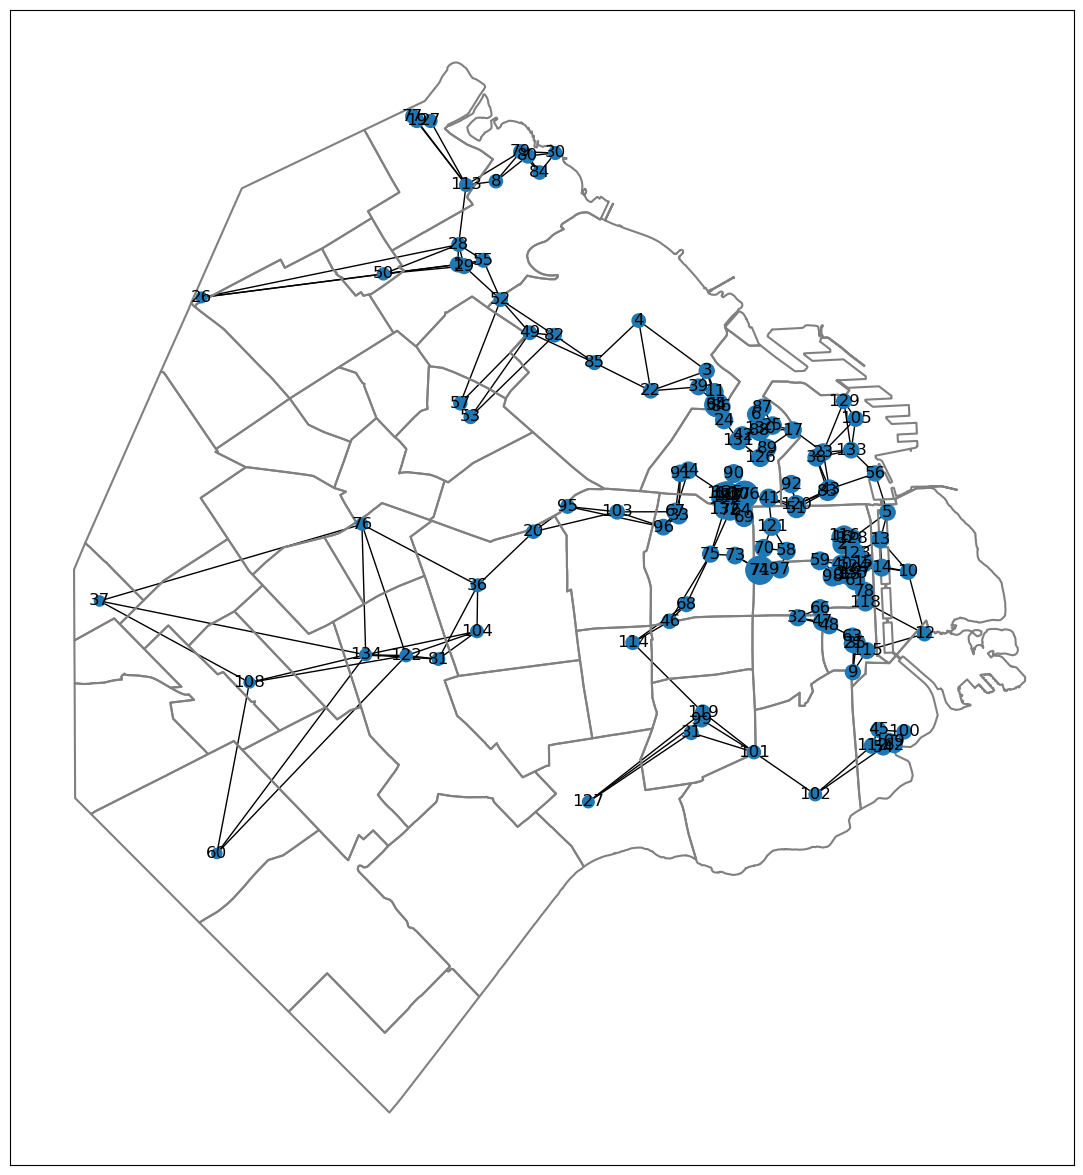

In [24]:
fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax, node_size=p * 20000) # Graficamos los museos

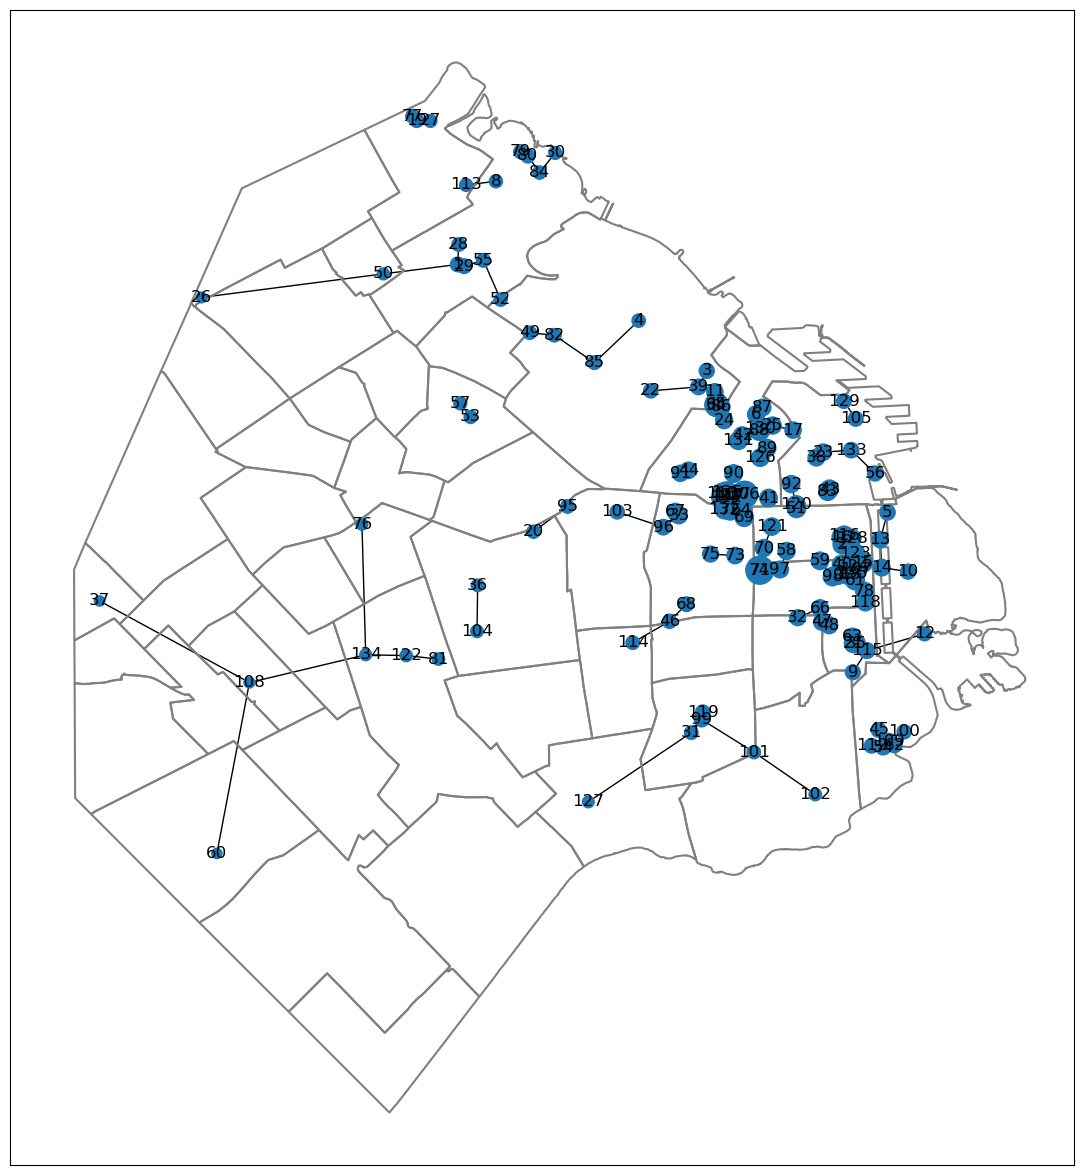

In [ ]:
# Cambiamos m = 1

m = 1
A = construye_adyacencia(D, m)

G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax, node_size=p * 20000) # Graficamos los museos

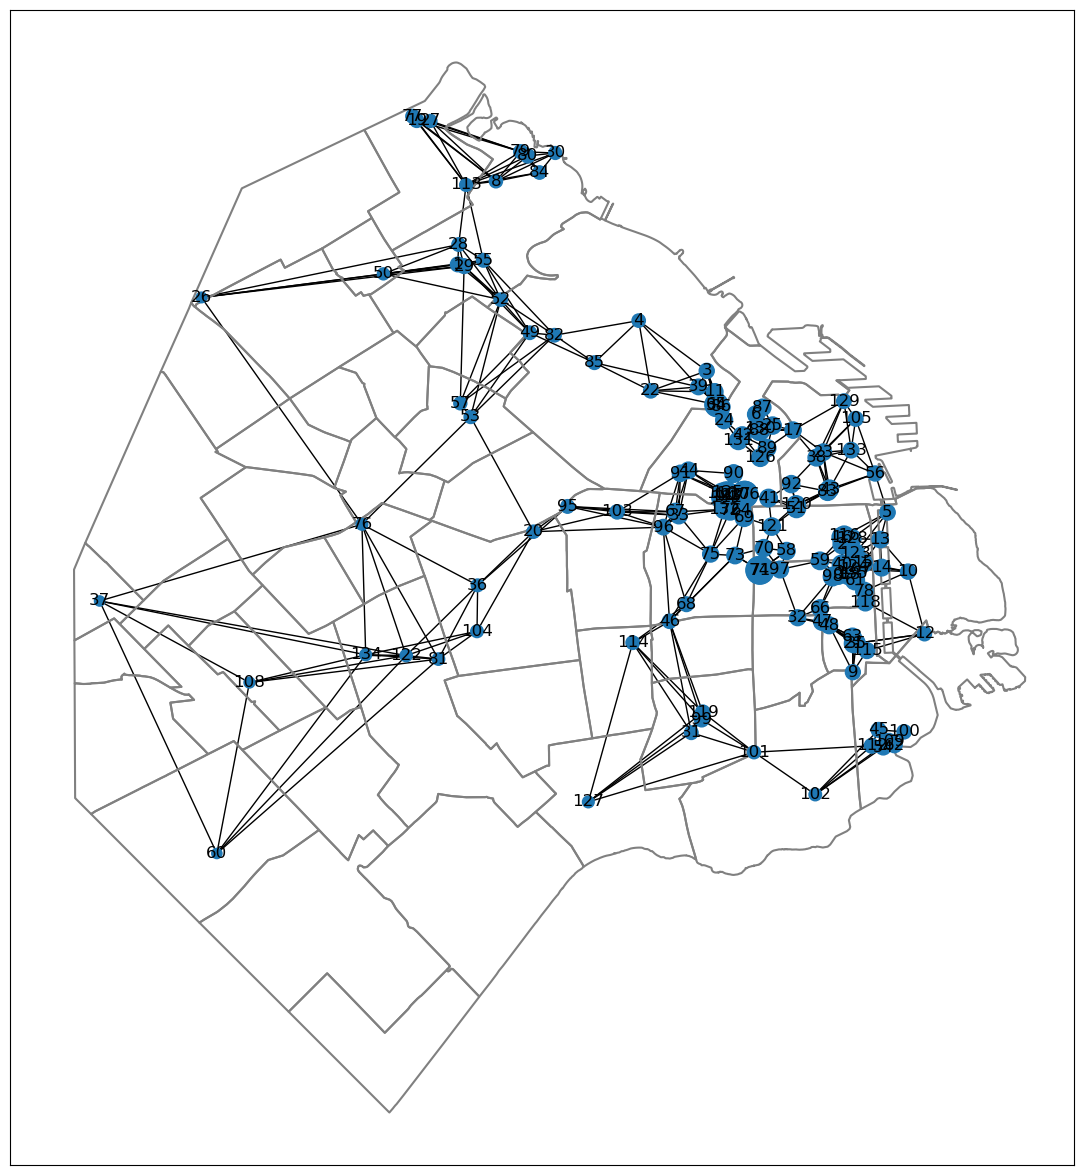

In [26]:
# Cambiamos m = 5

m = 5
A = construye_adyacencia(D, m)

G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax, node_size=p * 20000) # Graficamos los museos

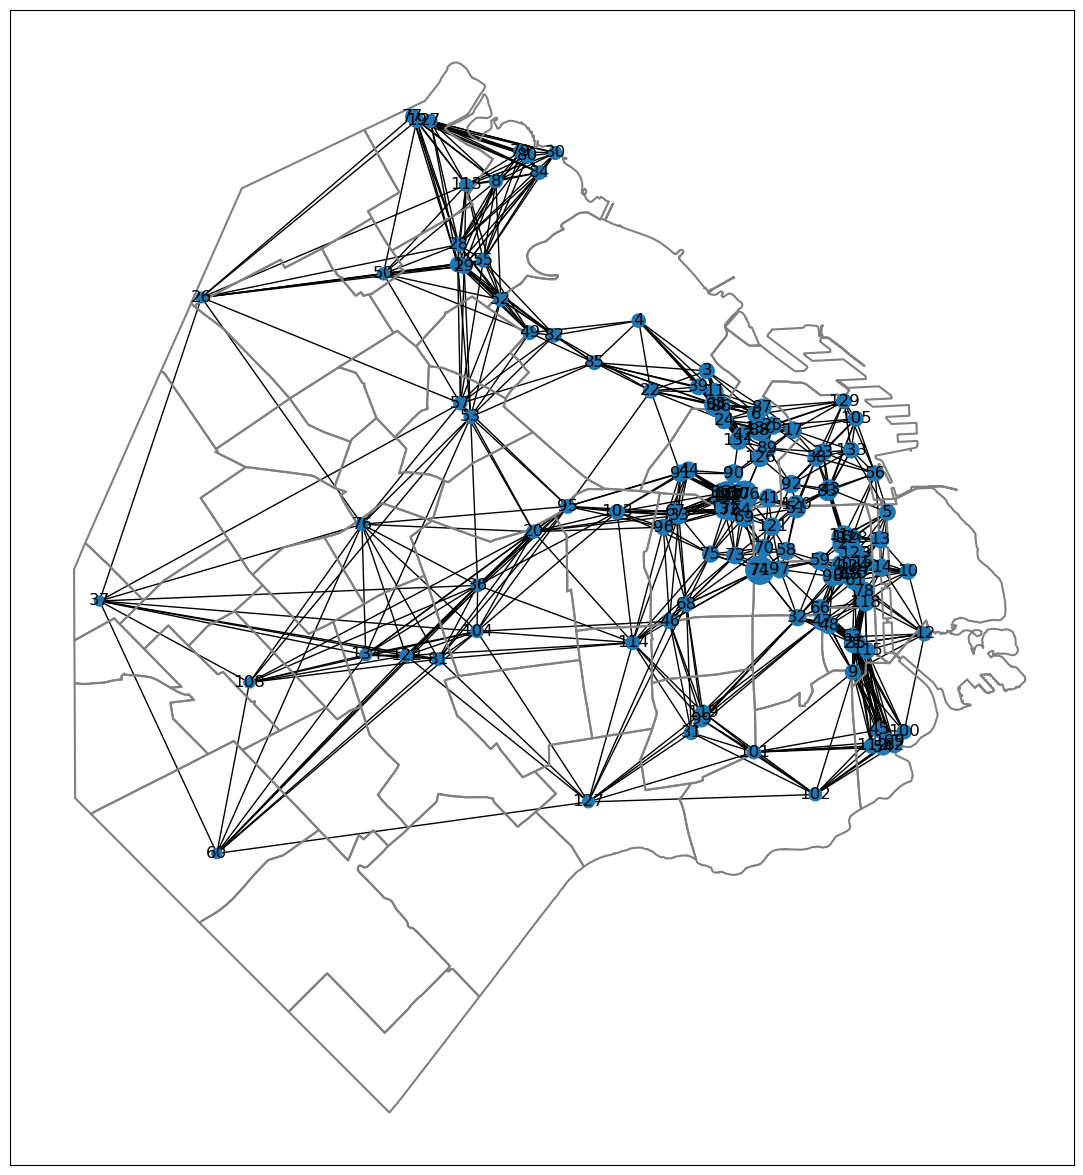

In [27]:
# Cambiamos m = 10

m = 10
A = construye_adyacencia(D, m)

G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax, node_size=p * 20000) # Graficamos los museos

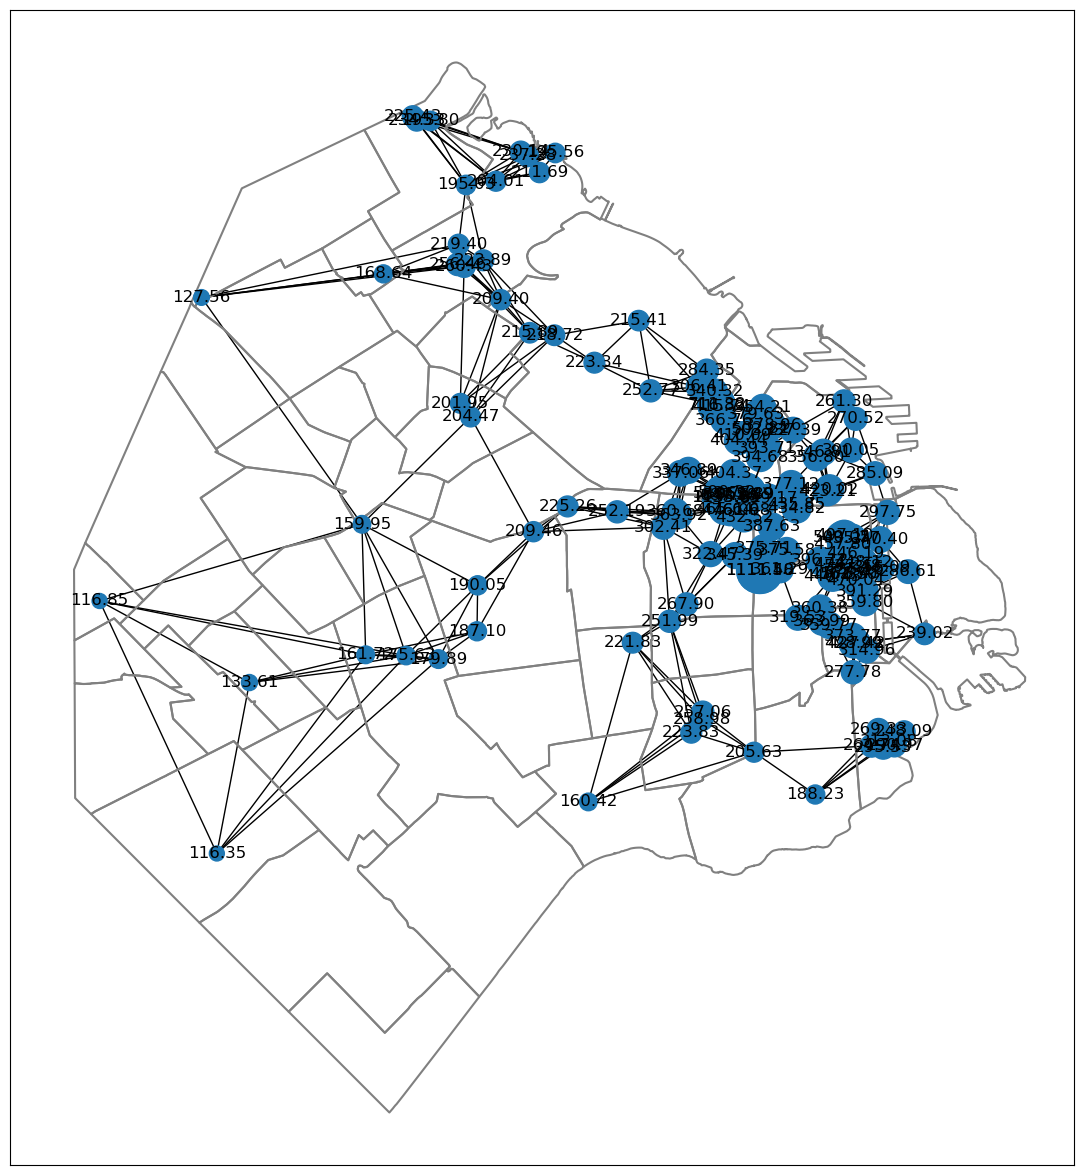

In [44]:
# Cambiamos a:

a = 1/7

M = (n/a) * ( np.eye(n) - ((1 - a) * C))

p = solucion_final(M, b) * 50000


m = 5
A = construye_adyacencia(D, m)

G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax, node_size=p, labels={i: f"{p[i]:.2f}" for i in range(D.shape[0])}) # Graficamos los museos

## Punto 4:

## Punto 5:

## Punto 6:

# Extras

Para graficar la red con un conjunto de puntajes (como el Page Rank)

{0: Text(4924405.086723215, 6160838.106023658, ''),
 1: Text(4917216.80489522, 6166701.553530234, ''),
 2: Text(4924486.298584606, 6161409.256658559, ''),
 3: Text(4921922.052887296, 6164690.544542129, ''),
 4: Text(4920636.67547965, 6165640.199444978, ''),
 5: Text(4925338.320928778, 6162016.528710163, ''),
 6: Text(4922856.100832731, 6163868.567721188, ''),
 7: Text(4922641.894255253, 6162355.100129171, ''),
 8: Text(4917938.7521918025, 6168273.372961773, ''),
 9: Text(4924683.52693892, 6158996.617208998, ''),
 10: Text(4925725.9600755945, 6160896.846339954, ''),
 11: Text(4922075.10183836, 6164294.738410278, ''),
 12: Text(4926038.146946977, 6159721.190876993, ''),
 13: Text(4925200.592014585, 6161503.005610317, ''),
 14: Text(4925229.168803978, 6160973.145341254, ''),
 15: Text(4924875.410406244, 6161061.981187101, ''),
 16: Text(4924474.294424794, 6161547.549492302, '16'),
 17: Text(4923553.755484842, 6163571.336254905, ''),
 18: Text(4924615.955668659, 6160843.2491330765, ''),
 1

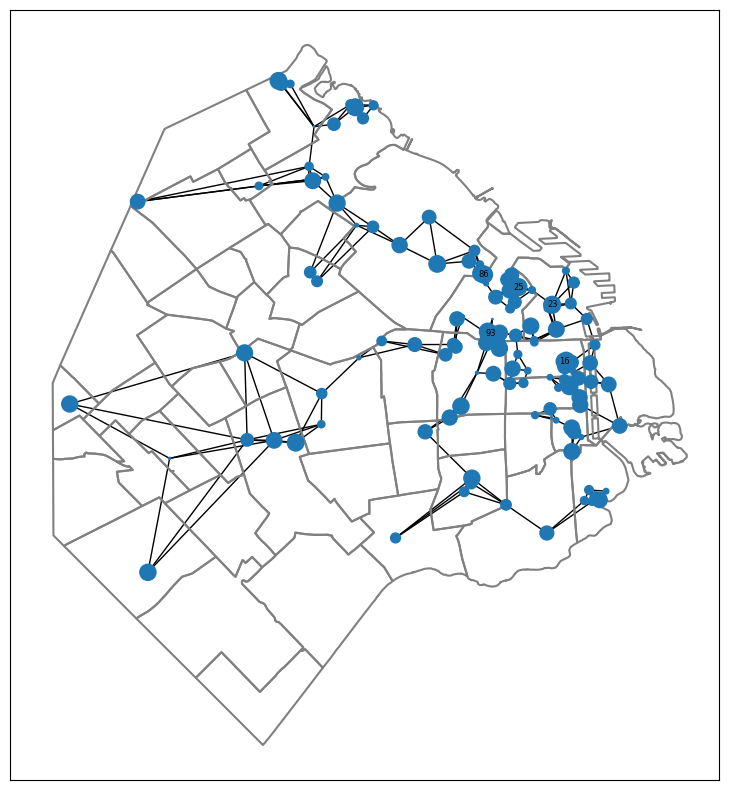

In [12]:
factor_escala = 1e4 # Escalamos los nodos 10 mil veces para que sean bien visibles
fig, ax = plt.subplots(figsize=(10, 10)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
pr = np.random.uniform(0,1,museos.shape[0])# Este va a ser su score Page Rank. Ahora lo reemplazamos con un vector al azar
pr = pr/pr.sum() # Normalizamos para que sume 1
Nprincipales = 5 # Cantidad de principales
principales = np.argsort(pr)[-Nprincipales:] # Identificamos a los N principales
labels = {n: str(n) if i in principales else "" for i, n in enumerate(G.nodes)} # Nombres para esos nodos
nx.draw_networkx(G,G_layout,node_size = pr*factor_escala, ax=ax,with_labels=False) # Graficamos red
nx.draw_networkx_labels(G, G_layout, labels=labels, font_size=6, font_color="k") # Agregamos los nombres